# **1. Data Preparation**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1N0h9cZiF-b-ihtAnOeu9WsDg3YFOb7B9")
df.head()

<ipython-input-2-d39c65cac671>:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://drive.google.com/uc?export=download&id=1N0h9cZiF-b-ihtAnOeu9WsDg3YFOb7B9")


,No SO,Tgl SO,No SI,ID Customer,Nama Customer,Subchannel,Kota,Provinsi,Salesman,Kode Barang,...,Nomor PO,Kts Terproses,Kts Belum Terproses,Status Pesanan Penjualan,Bulan,Tgl Akuisisi,Bulan Akuisisi,PIC,Main Produk,Main Channel
0,SO.2024.01.00001,1/3/2024,SI.2024.01.00100,TF00235,Zubair Frozen Food Up.Ramadhani,TOKO FROZEN,BANJARMASIN,KALIMANTAN SELATAN,Diah Frestia Rachmawati,DG0012,...,NaN,51.,0.,Terproses,01-24,31/12/2023,12-23,RBM West,Daging Kebab External,GT
1,SO.2024.01.00001,1/3/2024,SI.2024.01.00100,TF00235,Zubair Frozen Food Up.Ramadhani,TOKO FROZEN,BANJARMASIN,KALIMANTAN SELATAN,Diah Frestia Rachmawati,LN0002,...,NaN,5.,0.,Terproses,01-24,31/12/2023,12-23,RBM West,Perlengkapan Kebab,GT
2,SO.2024.01.00002,1/2/2024,SI.2024.01.00101,TF00130,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,TT0070,...,NaN,20.,0.,Terproses,01-24,31/12/2023,12-23,RBM East,Tortilla Tamma,GT
3,SO.2024.01.00002,1/2/2024,SI.2024.01.00101,TF00130,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,TT0015,...,NaN,10.,0.,Terproses,01-24,31/12/2023,12-23,RBM East,Tortilla Tamma,GT
4,SO.2024.01.00002,1/2/2024,SI.2024.01.00101,TF00130,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,KM0005,...,NaN,5.,0.,Terproses,01-24,31/12/2023,12-23,RBM East,Kemasan,GT


In [ ]:
df = df.drop(['No SO','No SI','ID Customer','Kode Barang','UoM', 'Harga','Diskon','DPP','PPN','Nilai SO','Tgl Request Pengiriman',
               'Waktu Create SO','Nomor PO','Kts Terproses','Kts Belum Terproses','Status Pesanan Penjualan','Bulan','Tgl Akuisisi',
               'Bulan Akuisisi','PIC'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34715 entries, 0 to 34714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Tgl SO           34715 non-null  object
 1   Nama Customer    34715 non-null  object
 2   Subchannel       34715 non-null  object
 3   Kota             34715 non-null  object
 4   Provinsi         34715 non-null  object
 5   Salesman         34715 non-null  object
 6   Nama Barang      34715 non-null  object
 7   Kategori Barang  34715 non-null  object
 8   Kuantitas        34715 non-null  object
 9   Total Harga      34715 non-null  object
 10  Main Produk      34715 non-null  object
 11  Main Channel     34715 non-null  object
dtypes: object(12)
memory usage: 3.2+ MB


In [ ]:
df.rename(columns={'Tgl SO':'Date'}, inplace=True)

In [ ]:
df[['Date']]=df[['Date']].apply(pd.to_datetime)

In [ ]:
df['Kuantitas'] = df['Kuantitas'].apply(lambda x: int(str(x).replace(",", "")))

In [ ]:
def clean_price(value):
    # Menghapus spasi dan mengganti koma dengan titik
    value = str(value).replace(" ", "").replace(".", "").replace(",", "")
    return int(value)

# Terapkan fungsi pembersihan pada kolom harga
df['Total Harga'] = df['Total Harga'].apply(clean_price)

In [ ]:
df['Kota'] = df['Kota'].str.upper()
df['Provinsi'] = df['Provinsi'].str.upper()

In [ ]:
df

,Date,Nama Customer,Subchannel,Kota,Provinsi,Salesman,Nama Barang,Kategori Barang,Kuantitas,Total Harga,Main Produk,Main Channel
0,2024-01-03,Zubair Frozen Food Up.Ramadhani,TOKO FROZEN,BANJARMASIN,KALIMANTAN SELATAN,Diah Frestia Rachmawati,Daging kebab sapi 2kg sahara premium,Daging,51,6987000,Daging Kebab External,GT
1,2024-01-03,Zubair Frozen Food Up.Ramadhani,TOKO FROZEN,BANJARMASIN,KALIMANTAN SELATAN,Diah Frestia Rachmawati,Sterofoam,Lainnya,5,133750,Perlengkapan Kebab,GT
2,2024-01-02,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,Tortilla Sedang TAMMA,Tortilla,20,420000,Tortilla Tamma,GT
3,2024-01-02,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,Tortilla Besar TAMMA,Tortilla,10,230000,Tortilla Tamma,GT
4,2024-01-02,Lydia/Lina,TOKO FROZEN,TULUNGAGUNG,JAWA TIMUR,Deni Ratna Susanti,Kemasan Kebab Merah Putih,Kemasan,5,205000,Kemasan,GT
...,...,...,...,...,...,...,...,...,...,...,...,...
34710,2024-12-23,Ratna Yisan,TOKO FROZEN,JAKARTA SELATAN,DKI JAKARTA,Diah Frestia Rachmawati,Tortilla Catering Tortillaku 650gr (Merah),Tortilla,10,179440,Tortillaku,GT
34711,2024-12-23,Ratna Yisan,TOKO FROZEN,JAKARTA SELATAN,DKI JAKARTA,Diah Frestia Rachmawati,Tortilla Mini Tortillaku 850gr (Merah),Tortilla,10,200180,Tortillaku,GT
34712,2024-12-23,Ratna Yisan,TOKO FROZEN,JAKARTA SELATAN,DKI JAKARTA,Diah Frestia Rachmawati,Tortilla Sedang Tortillaku 1050gr (Merah),Tortilla,20,450840,Tortillaku,GT
34713,2024-12-23,Ratna Yisan,TOKO FROZEN,JAKARTA SELATAN,DKI JAKARTA,Diah Frestia Rachmawati,Tortilla Besar Tortillaku 1250gr (Merah),Tortilla,10,246160,Tortillaku,GT


## **2. Exploratory Data Analysis**

## Omzet by Province

In [ ]:
sales_prov = df.groupby(['Provinsi'])[['Total Harga','Kuantitas']].sum().reset_index()
sales_prov

,Provinsi,Total Harga,Kuantitas
0,BALI,5115723551,231804
1,BANGKA BELITUNG,61233180,2780
2,BANTEN,1298654064,61236
3,DI YOGYAKARTA,3364136320,159872
4,DKI JAKARTA,7209327092,345611
5,JAWA BARAT,7517403266,360016
6,JAWA TENGAH,4020578388,190370
7,JAWA TIMUR,19314881390,748273
8,KALIMANTAN BARAT,71755964,2635
9,KALIMANTAN SELATAN,1215988910,10321


In [ ]:
top10_prov = sales_prov.sort_values(by='Total Harga', ascending=False).head(10)

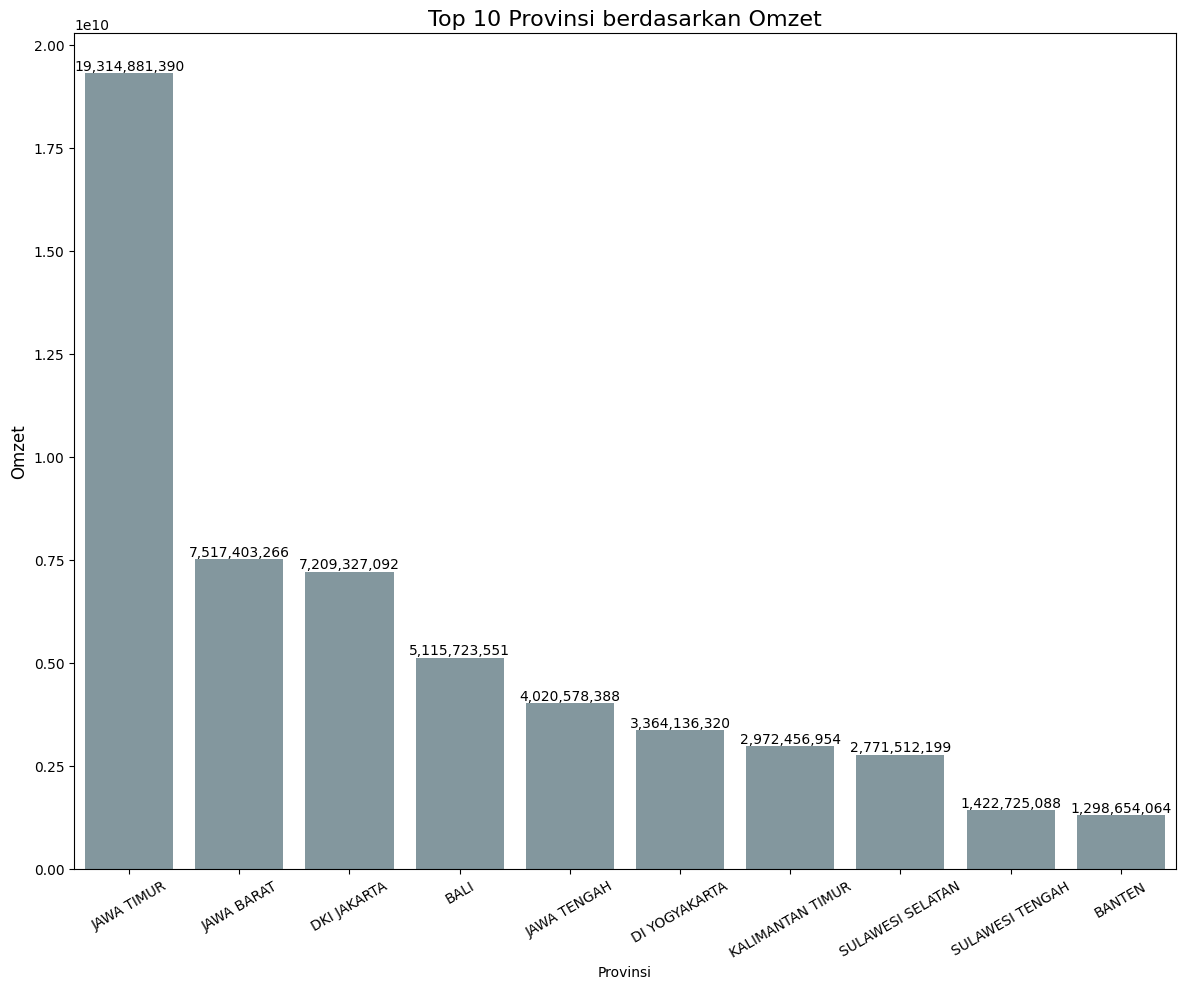

In [ ]:
plt.figure(figsize=(12, 10))
sns.barplot(x = 'Provinsi', y = 'Total Harga', data = top10_prov,
            color='#7E99A3')
for index, row in top10_prov.iterrows():
    plt.text(x=row['Provinsi'],
             y=row['Total Harga'] + 85000000,
             s=f"{row['Total Harga']:,}",
             ha='center',
             fontsize=10)

plt.title('Top 10 Provinsi berdasarkan Omzet', fontsize=16)
plt.xlabel('Provinsi', fontsize=10)
plt.ylabel('Omzet', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Omzet by Kota

In [ ]:
sales_city = df.groupby(['Kota'])[['Total Harga','Kuantitas']].sum().reset_index()
sales_city

,Kota,Total Harga,Kuantitas
0,BADUNG,62493986,2303
1,BALI,1032132224,46650
2,BALIKPAPAN,267377415,11331
3,BALIKPAPAN BARAT,1700000,1
4,BANDAR LAMPUNG,756054474,36090
...,...,...,...
120,TRENGGALEK,33020635,1520
121,TUBAN,75659602,3241
122,TULUNGAGUNG,87838635,2989
123,WONOSOBO,701901,27


In [ ]:
top10_city = sales_city.sort_values(by='Total Harga', ascending=False).head(10)
low10_city = sales_city.sort_values(by='Total Harga', ascending=True).head(10)

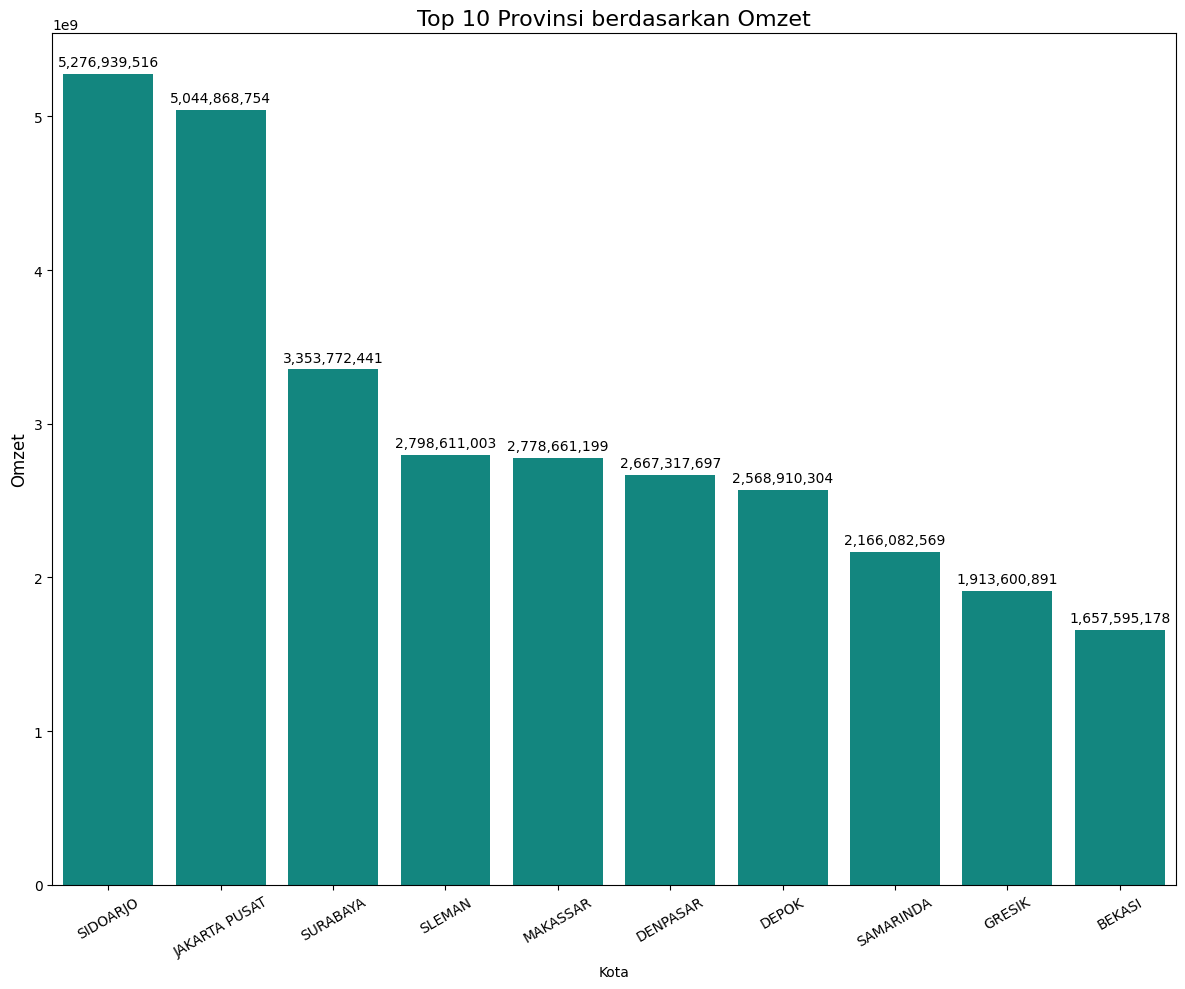

In [ ]:
plt.figure(figsize=(12, 10))
sns.barplot(x = 'Kota', y = 'Total Harga', data = top10_city,
            color='#009990')
for index, row in top10_city.iterrows():
    plt.text(x=row['Kota'],
             y=row['Total Harga'] + 50000000,
             s=f"{row['Total Harga']:,}",
             ha='center',
             fontsize=10)

plt.title('Top 10 Provinsi berdasarkan Omzet', fontsize=16)
plt.xlabel('Kota', fontsize=10)
plt.ylabel('Omzet', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

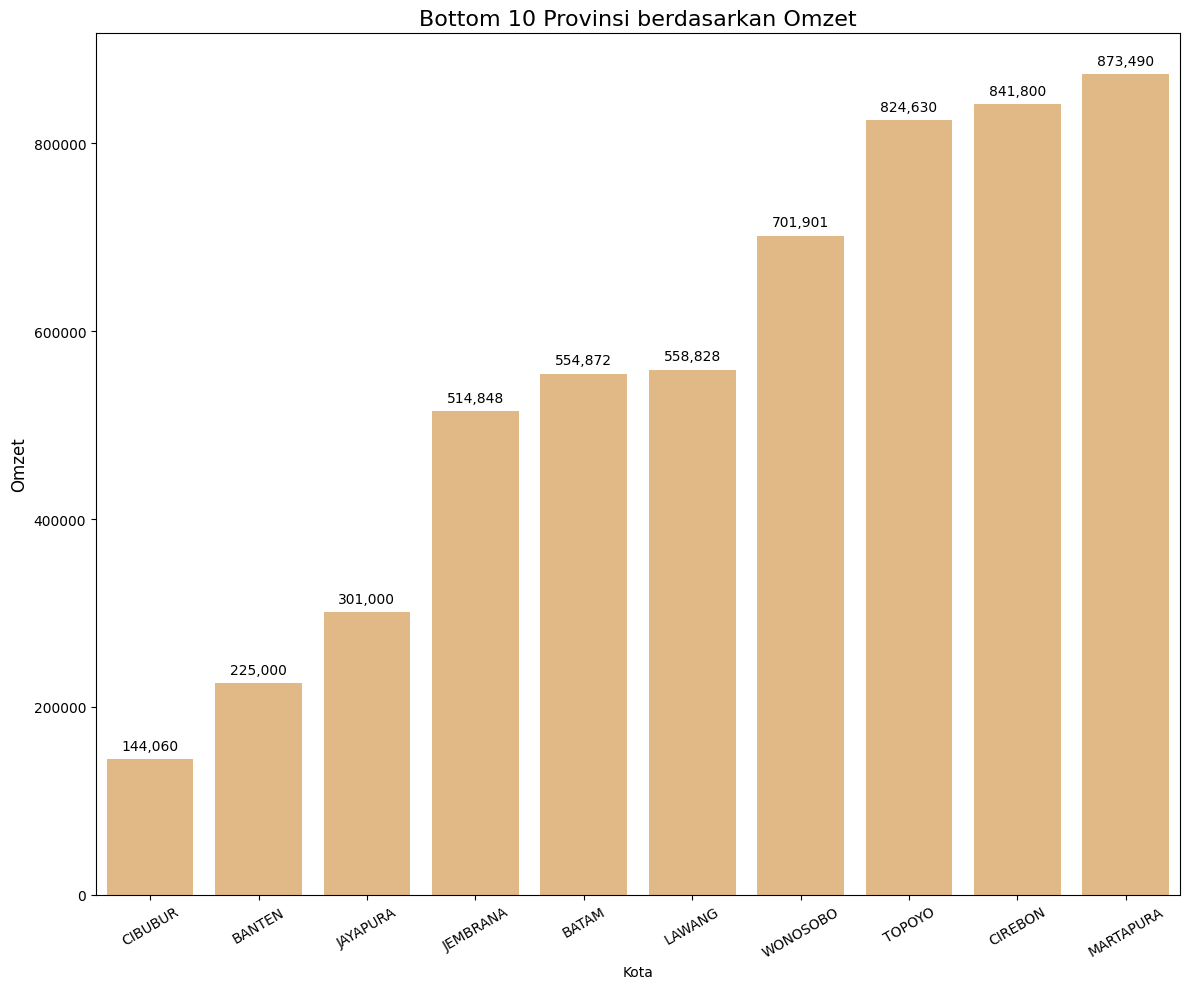

In [ ]:
plt.figure(figsize=(12, 10))
sns.barplot(x = 'Kota', y = 'Total Harga', data = low10_city,
            color='#F0BB78')
for index, row in low10_city.iterrows():
    plt.text(x=row['Kota'],
             y=row['Total Harga'] + 10000,
             s=f"{row['Total Harga']:,}",
             ha='center',
             fontsize=10)

plt.title('Bottom 10 Provinsi berdasarkan Omzet', fontsize=16)
plt.xlabel('Kota', fontsize=10)
plt.ylabel('Omzet', fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Omzet by Main Produk

In [ ]:
sales_mp = df.groupby(['Main Produk'])[['Total Harga','Kuantitas']].sum().reset_index()

In [ ]:
sales_mp

,Main Produk,Total Harga,Kuantitas
0,Daging Kebab External,6456393108,43257
1,Daging Kebab Internal,744573300,10284
2,Kebab Frozen,4664029726,224990
3,Kemasan,1221256420,25450
4,Perlengkapan Kebab,180351739,10156
5,Roti,871538329,61085
6,Tortilla Makloon,3151379250,152464
7,Tortilla Tamma,24779366670,1185513
8,Tortillaku,16449776527,732843


In [ ]:
top_mp = sales_mp.sort_values(by='Total Harga', ascending=False).head(10)
top_mp

,Main Produk,Total Harga,Kuantitas
7,Tortilla Tamma,24779366670,1185513
8,Tortillaku,16449776527,732843
0,Daging Kebab External,6456393108,43257
2,Kebab Frozen,4664029726,224990
6,Tortilla Makloon,3151379250,152464
3,Kemasan,1221256420,25450
5,Roti,871538329,61085
1,Daging Kebab Internal,744573300,10284
4,Perlengkapan Kebab,180351739,10156


In [ ]:
selected_indices = [7, 8, 0, 2]
mp_1 = top_mp.loc[selected_indices]
mp_2 = top_mp.drop(selected_indices)
mp_3 = pd.DataFrame({
    'Main Produk': ['Lainnya'],
    'Total Harga': [mp_2['Total Harga'].sum()],
    'Kuantitas': [mp_2['Kuantitas'].sum()]
})
mp_comb = pd.concat([mp_1, mp_3], ignore_index=True)
mp_comb = mp_comb.sort_values(by='Total Harga', ascending=False)

In [ ]:
mp_comb

,Main Produk,Total Harga,Kuantitas
0,Tortilla Tamma,24779366670,1185513
1,Tortillaku,16449776527,732843
2,Daging Kebab External,6456393108,43257
4,Lainnya,6169099038,259439
3,Kebab Frozen,4664029726,224990


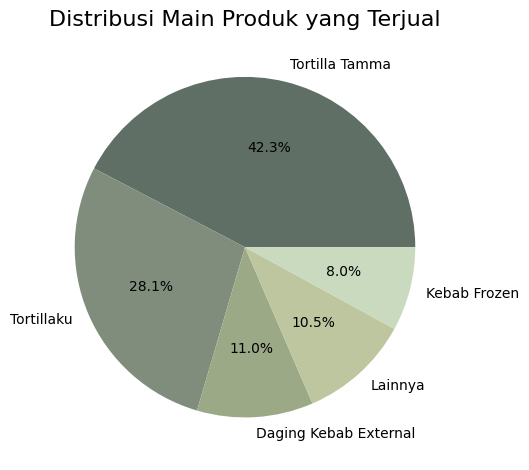

In [ ]:
color = ['#5F6F65','#808D7C','#9CA986','#BEC6A0','#C9DABF']
plt.pie(
    mp_comb['Total Harga'],
    labels=mp_comb['Main Produk'],
    autopct='%1.1f%%', colors=color
)
plt.title('Distribusi Main Produk yang Terjual', fontsize=16)
plt.tight_layout()
plt.show()

# **3. ARIMA MODELING**

## Prepare Dataset

In [ ]:
df1 = df.drop(['Nama Customer','Subchannel','Kota','Provinsi','Salesman',
               'Nama Barang','Kategori Barang','Main Produk','Main Channel','Kuantitas'], axis=1)

df1.head()

,Date,Total Harga
0,2024-01-03,6987000
1,2024-01-03,133750
2,2024-01-02,420000
3,2024-01-02,230000
4,2024-01-02,205000


### Grouping by Day

In [ ]:
df1_d = df1.groupby('Date').agg({'Total Harga': 'sum'}).reset_index()

In [ ]:
df1_d

,Date,Total Harga
0,2024-01-02,331181720
1,2024-01-03,219944080
2,2024-01-04,172823270
3,2024-01-05,61947170
4,2024-01-06,70586290
...,...,...
290,2024-12-18,134585841
291,2024-12-19,215241209
292,2024-12-20,297399088
293,2024-12-21,127014862


### Interpolating missing value after asfreq

In [ ]:
df1_d = df1_d.set_index('Date')
df1_d = df1_d.asfreq('D')
df1_d = df1_d.interpolate(method='linear')
df1_d = df1_d.reset_index()
df1_d

,Date,Total Harga
0,2024-01-02,331181720.0
1,2024-01-03,219944080.0
2,2024-01-04,172823270.0
3,2024-01-05,61947170.0
4,2024-01-06,70586290.0
...,...,...
352,2024-12-19,215241209.0
353,2024-12-20,297399088.0
354,2024-12-21,127014862.0
355,2024-12-22,335262747.0


In [ ]:
df1_d = df1_d.set_index('Date')

In [ ]:
df1_d

,Total Harga
Date,
2024-01-02,331181720.0
2024-01-03,219944080.0
2024-01-04,172823270.0
2024-01-05,61947170.0
2024-01-06,70586290.0
...,...
2024-12-19,215241209.0
2024-12-20,297399088.0
2024-12-21,127014862.0


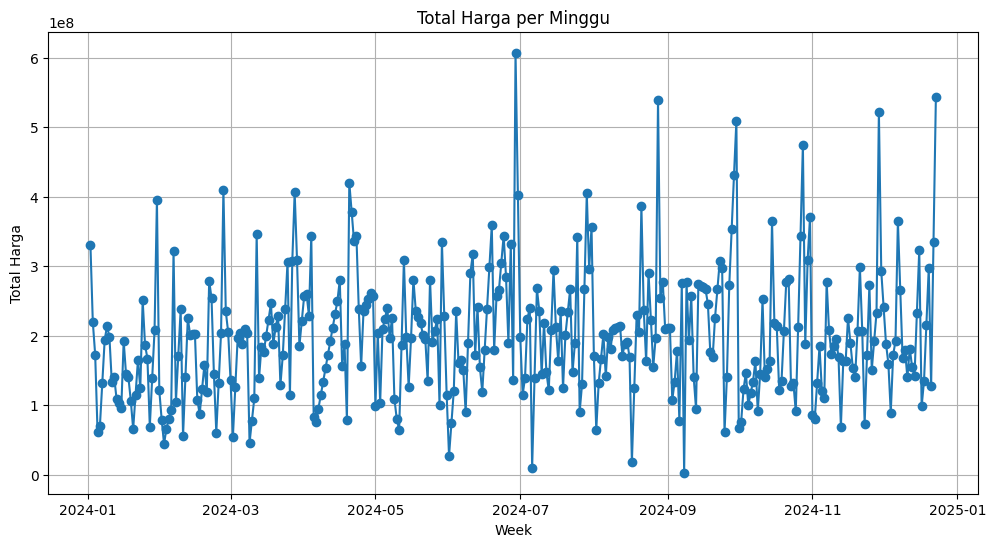

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df1_d['Total Harga'], marker='o', linestyle='-')

plt.title('Total Harga per Minggu')
plt.xlabel('Week')
plt.ylabel('Total Harga')
plt.grid(True)
plt.show()

### Handling outlier

In [ ]:
df1_o = df1_d.reset_index()

In [ ]:
df1_o['zscore'] = zscore(df1_o['Total Harga'])
df1_o.head()

,Date,Total Harga,zscore
0,2024-01-02,331181720.0,1.433847
1,2024-01-03,219944080.0,0.228166
2,2024-01-04,172823270.0,-0.282567
3,2024-01-05,61947170.0,-1.484330
4,2024-01-06,70586290.0,-1.390692


In [ ]:
outliers = df1_o[df1_o['zscore'].abs() > 3]
outliers

,Date,Total Harga,zscore
179,2024-06-29,607335573.0,4.427021
239,2024-08-28,539137844.0,3.687840
272,2024-09-30,509647122.0,3.368196
332,2024-11-29,522695013.0,3.509620
356,2024-12-23,543510632.0,3.735236


In [ ]:
df1_o.drop(index=356, inplace=True)
df1_o.loc[df1_o['zscore'] > 3, 'Total Harga'] = np.nan
df1_o

,Date,Total Harga,zscore
0,2024-01-02,331181720.0,1.433847
1,2024-01-03,219944080.0,0.228166
2,2024-01-04,172823270.0,-0.282567
3,2024-01-05,61947170.0,-1.484330
4,2024-01-06,70586290.0,-1.390692
...,...,...,...
351,2024-12-18,134585841.0,-0.697014
352,2024-12-19,215241209.0,0.177192
353,2024-12-20,297399088.0,1.067684
354,2024-12-21,127014862.0,-0.779074


In [ ]:
df1_o = df1_o.set_index('Date')
df1_o = df1_o.drop('zscore', axis=1)
df1_o.interpolate(method='linear', inplace=True)
df1_o.head()

,Total Harga
Date,
2024-01-02,331181720.0
2024-01-03,219944080.0
2024-01-04,172823270.0
2024-01-05,61947170.0
2024-01-06,70586290.0


In [ ]:
# df1_d = df1_o.reset_index()

In [ ]:
shapiro_test = stats.shapiro(df1_o['Total Harga'])
print('Shapiro-Wilk Test Statistic:', shapiro_test.statistic)
print('p-value:', shapiro_test.pvalue)

Shapiro-Wilk Test Statistic: 0.9851625403940667
p-value: 0.0010216784209790635


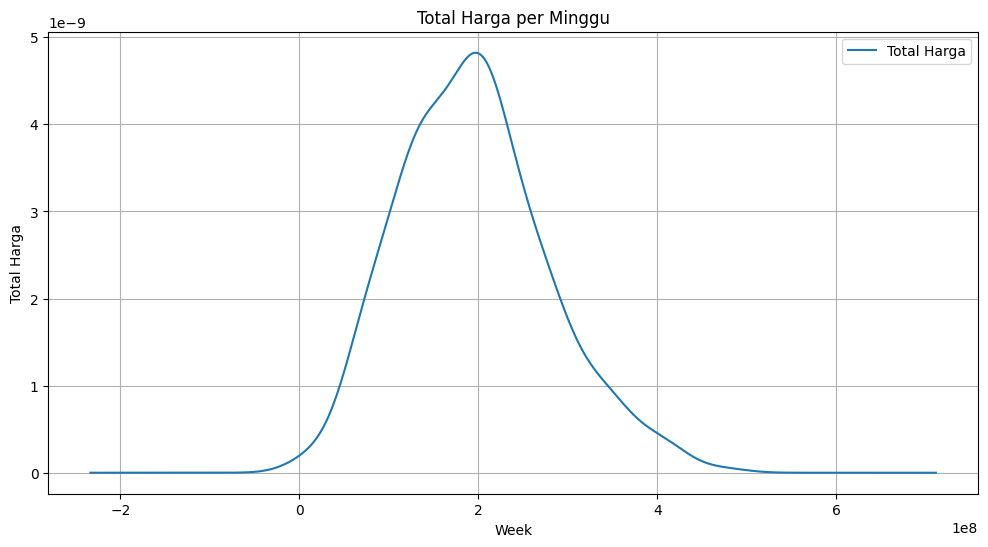

In [ ]:
df1_o.plot(kind='kde', figsize=(12, 6))
plt.title('Total Harga per Minggu')
plt.xlabel('Week')
plt.ylabel('Total Harga')
plt.grid(True)

In [ ]:
df1_o['Total Harga(bc)'], lambda_value = stats.boxcox(df1_o['Total Harga']+1)
print(f"Optimal lambda value: {lambda_value}")

Optimal lambda value: 0.6717325553104392


In [ ]:
shapiro_stat, shapiro_p_value = stats.shapiro(df1_o['Total Harga(bc)'])

print(f"Shapiro-Wilk Test Statistic: {shapiro_stat}")
print(f"p-value: {shapiro_p_value}")

Shapiro-Wilk Test Statistic: 0.9974070862985154
p-value: 0.851819979740033


In [ ]:
df1_o

,Total Harga,Total Harga(bc)
Date,,
2024-01-02,331181720.0,787061.607636
2024-01-03,219944080.0,597867.941017
2024-01-04,172823270.0,508473.028469
2024-01-05,61947170.0,255244.015662
2024-01-06,70586290.0,278639.234149
...,...,...
2024-12-18,134585841.0,429848.704376
2024-12-19,215241209.0,589250.276329
2024-12-20,297399088.0,732184.961359


In [ ]:
df1_t = df1_o.drop('Total Harga', axis=1)
df1_t

,Total Harga(bc)
Date,
2024-01-02,787061.607636
2024-01-03,597867.941017
2024-01-04,508473.028469
2024-01-05,255244.015662
2024-01-06,278639.234149
...,...
2024-12-18,429848.704376
2024-12-19,589250.276329
2024-12-20,732184.961359


In [ ]:
adf_test = adfuller(df1_t['Total Harga(bc)'])
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])
print('Critical Values:')
for key, value in adf_test[4].items():
	print('\t%s: %.3f' % (key, value))

# Jika p-value < 0.05 = Data Stasioner

ADF Statistic: -12.056930
p-value: 0.000000
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571


In [ ]:
kpss_test, p_value, lags, critical_values = kpss(df1_t, regression='c', nlags="auto")
print(f"Statistik KPSS: {kpss_test}")
print(f"P-Value: {p_value}")
print("Critical Values:")
for key, value in critical_values.items():
    print(f"  {key}: {value}")

# Jika p-value < 0.05 = Data tidak stasioner

Statistik KPSS: 0.46922364488630475
P-Value: 0.048598278178760196
Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739


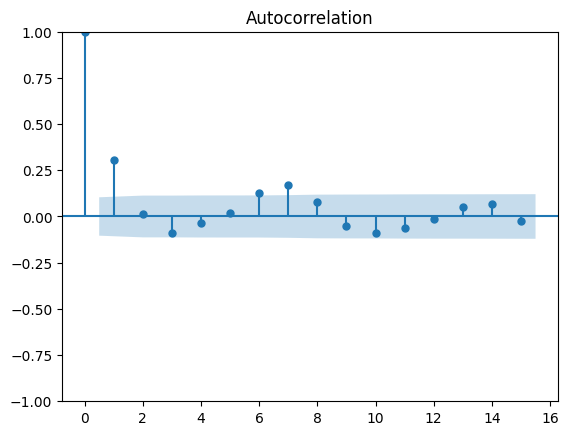

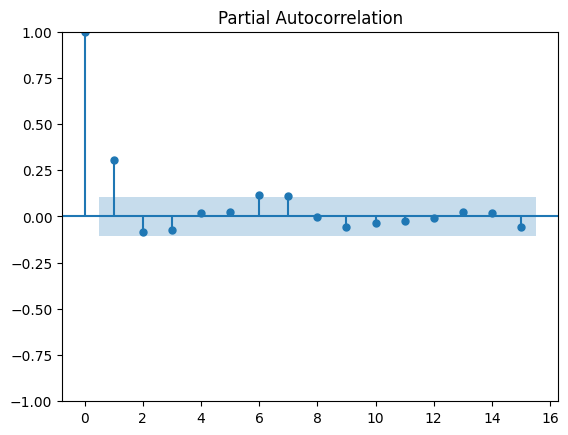

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df1_t['Total Harga(bc)'], lags=15)
plot_pacf(df1_t['Total Harga(bc)'], lags=15)
plt.show()

In [ ]:
target = df1_t['Total Harga(bc)']
train_data, test_data = train_test_split(target, test_size=0.1, random_state=42)
print(f'Ukuran Data Latih: {train_data.shape[0]}, Ukuran Data Uji: {test_data.shape[0]}')


Ukuran Data Latih: 320, Ukuran Data Uji: 36


In [ ]:
# # Fungsi untuk mengevaluasi model ARIMA berdasarkan RMSE dan MSE
# def evaluate_arima_model(train, test, p, d, q):
#     try:
#         # Membuat dan melatih model ARIMA
#         model = ARIMA(train_data, order=(p, d, q))
#         model_fit = model.fit()

#         # Melakukan prediksi pada data test
#         predictions = model_fit.forecast(steps=len(test_data))

#         # Menghitung RMSE dan MSE
#         rmse = np.sqrt(mean_squared_error(test_data, predictions))
#         mse = mean_squared_error(test_data, predictions)

#         return rmse, mse
#     except Exception as e:
#         print(f"Error with parameters (p={p}, d={d}, q={q}): {e}")
#         return float('inf'), float('inf')

# # Daftar nilai p dan q yang akan dicoba (Anda bisa menyesuaikan)
# p_values = [1, 2]
# q_values = [1]
# d = 0  # Anda bisa menyesuaikan jika ingin mencoba nilai d selain 0

# # Variabel untuk menyimpan hasil terbaik
# best_rmse, best_mse = float('inf'), float('inf')
# best_order_rmse, best_order_mse = None, None
# results = []

# # Mengiterasi berbagai kombinasi parameter p dan q
# for p in p_values:
#     for q in q_values:
#         # Evaluasi model untuk setiap kombinasi p, d, q
#         rmse, mse = evaluate_arima_model(train_data, test_data, p, d, q)

#         # Menyimpan hasil evaluasi
#         results.append((p, d, q, rmse, mse))

#         # Memperbarui hasil terbaik berdasarkan RMSE dan MSE
#         if rmse < best_rmse:
#             best_rmse, best_order_rmse = rmse, (p, d, q)
#         if mse < best_mse:
#             best_mse, best_order_mse = mse, (p, d, q)

# # Menampilkan hasil evaluasi dalam bentuk DataFrame
# results_df = pd.DataFrame(results, columns=['p', 'd', 'q', 'RMSE', 'MSE'])

# # Menampilkan hasil terbaik berdasarkan RMSE dan MSE
# print(f"Best RMSE: {best_rmse} for order {best_order_rmse}")
# print(f"Best MSE: {best_mse} for order {best_order_mse}")
# print("\nAll Results:")
# print(results_df)

In [ ]:
model = ARIMA(df1_t['Total Harga(bc)'], order=(1, 0, 1))
model_fit = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:        Total Harga(bc)   No. Observations:                  356
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -4752.887
Date:                Wed, 25 Dec 2024   AIC                           9513.773
Time:                        15:08:28   BIC                           9529.273
Sample:                    01-02-2024   HQIC                          9519.939
                         - 12-22-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.389e+05   1.12e+04     48.311      0.000    5.17e+05    5.61e+05
ar.L1          0.1424      0.170      0.839      0.401      -0.190       0.475
ma.L1          0.1862      0.162      1.148      0.2

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import itertools
import pandas as pd
import numpy as np

# Fungsi untuk melatih ARIMA dan menghitung AIC, RMSE, dan MSE
def evaluate_arima(data, train_size, p, d, q):
    try:
        # Membagi data menjadi train dan test
        train_data = data[:train_size]
        test_data = data[train_size:]

        # Melatih model ARIMA
        model = ARIMA(train_data, order=(p, d, q))
        model_fit = model.fit()

        # Prediksi pada data test
        predictions = model_fit.forecast(steps=len(test_data))

        # Menghitung RMSE dan MSE
        rmse = np.sqrt(mean_squared_error(test_data, predictions))
        mse = mean_squared_error(test_data, predictions)

        # Mengembalikan AIC, RMSE, dan MSE
        return model_fit.aic, rmse, mse
    except Exception as e:
        # Jika terjadi error, kembalikan nilai default
        print(f"Error with parameters (p={p}, d={d}, q={q}): {e}")
        return float('inf'), float('inf'), float('inf')

# Parameter grid untuk p, d, q
p_values = [0, 1, 2, 3]
d_values = [0]
q_values = [0, 1, 2, 3]

# Kombinasi semua parameter (p, d, q)
parameter_combinations = list(itertools.product(p_values, d_values, q_values))

# Data yang akan digunakan (ubah sesuai dataset Anda)
data = df1_t['Total Harga(bc)']  # Kolom target time series
train_size = int(len(data) * 0.8)  # 80% data untuk training
results = []

# Loop untuk mencoba semua kombinasi parameter
for param in parameter_combinations:
    p, d, q = param
    aic, rmse, mse = evaluate_arima(data, train_size, p, d, q)
    results.append((p, d, q, aic, rmse, mse))

# Menyimpan hasil evaluasi dalam bentuk DataFrame
results_df = pd.DataFrame(results, columns=['p', 'd', 'q', 'AIC', 'RMSE', 'MSE'])

# Menentukan parameter terbaik berdasarkan RMSE
best_result_rmse = results_df.loc[results_df['RMSE'].idxmin()]
best_result_mse = results_df.loc[results_df['MSE'].idxmin()]

# Menampilkan hasil terbaik
print(f"Best Parameters by RMSE: p={best_result_rmse['p']}, d={best_result_rmse['d']}, q={best_result_rmse['q']}")
print(f"Lowest RMSE: {best_result_rmse['RMSE']}")
print(f"Best Parameters by MSE: p={best_result_mse['p']}, d={best_result_mse['d']}, q={best_result_mse['q']}")
print(f"Lowest MSE: {best_result_mse['MSE']}")
print("\nAll Results:")
print(results_df.sort_values(by='RMSE'))

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best Parameters by RMSE: p=3.0, d=0.0, q=2.0
Lowest RMSE: 145672.3767222374
Best Parameters by MSE: p=3.0, d=0.0, q=2.0
Lowest MSE: 21220441339.90545

All Results:
    p  d  q          AIC           RMSE           MSE
14  3  0  2  7583.120034  145672.376722  2.122044e+10
11  2  0  3  7586.377347  148058.517918  2.192132e+10
0   0  0  0  8946.903313  149648.368516  2.239463e+10
1   0  0  1  7597.373310  150062.587612  2.251878e+10
4   1  0  0  7596.164507  150126.379801  2.253793e+10
5   1  0  1  7597.457523  150172.245551  2.255170e+10
8   2  0  0  7597.077827  150230.975267  2.256935e+10
7   1  0  3  7600.108261  150272.904712  2.258195e+10
6   1  0  2  7598.188971  150295.709762  2.258880e+10
2   0  0  2  7596.499063  150300.362273  2.259020e+10
3   0  0  3  7598.094878  150340.347428  2.260222e+10
9   2  0  1  7598.449268  150405.882627  2.262193e+10
13  3  0  1  7599.105703  150723.393463  2.271754e+10
12  3  0  0  7597.140451  150747.355105  2.272477e+10
10  2  0  2  7597.637268  

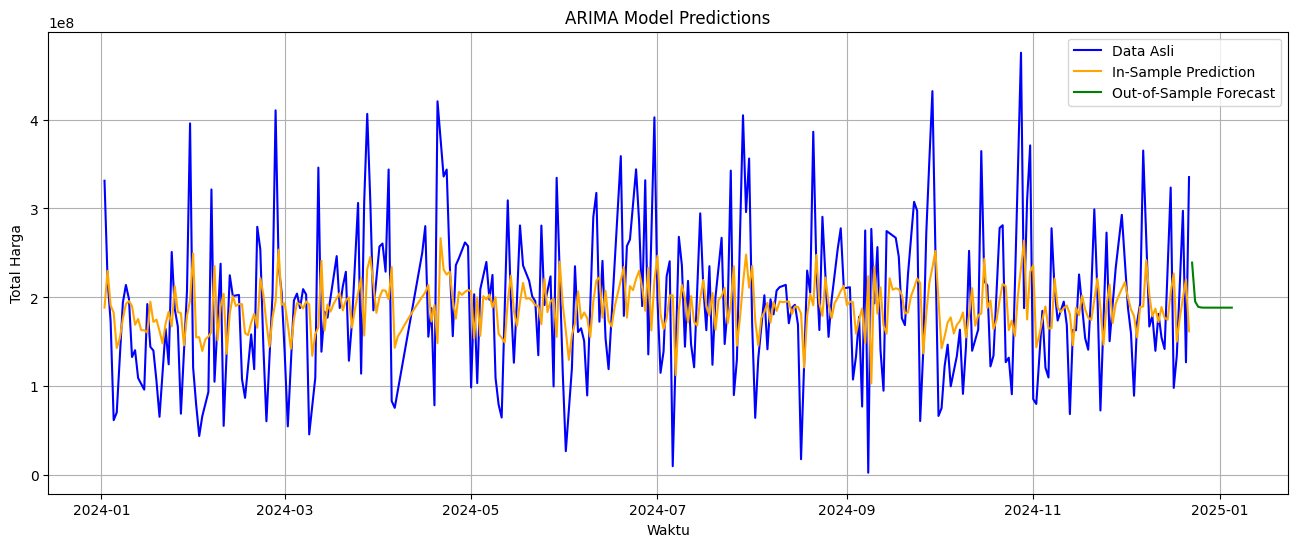

In [ ]:
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox

in_sample_predictions = model_fit.fittedvalues

# Melakukan prediksi out-of-sample (data di luar pelatihan)
# Misalnya, prediksi untuk 30 langkah ke depan
out_of_sample_forecast = model_fit.forecast(steps=14)

# Pastikan index berupa datetime
df1_t.index = pd.to_datetime(df1_t.index)

# Inversi transformasi Box-Cox untuk data asli dan prediksi
original_data = inv_boxcox(df1_t['Total Harga(bc)'], lambda_value)
in_sample_predictions = inv_boxcox(model_fit.fittedvalues, lambda_value)
out_of_sample_forecast = inv_boxcox(out_of_sample_forecast, lambda_value)

# Rentang waktu untuk prediksi out-of-sample
future_index = pd.date_range(start=df1_t.index[-1], periods=14 + 1, freq='D')[1:]

# Visualisasi
plt.figure(figsize=(16, 6))
plt.plot(df1_t.index, original_data, label='Data Asli', color='blue')
plt.plot(df1_t.index, in_sample_predictions, label='In-Sample Prediction', color='orange')
plt.plot(future_index, out_of_sample_forecast, label='Out-of-Sample Forecast', color='green')

plt.title('ARIMA Model Predictions')
plt.xlabel('Waktu')
plt.ylabel('Total Harga')
plt.legend()
plt.grid()
plt.show()